Edd Alexander Garza Robles 2045082
Lunes N1
Programacion para Inteligencia Artificial
Examen ordinario
25/Mayo/2026

Sección I ////
1- c .
2- b .
3- b .
4- a .
5- a .
6- c .

In [74]:
# Seccion II
# importar librerias y data frame de sklearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine

In [75]:
# Paso 1 Convertir a dataframe de pandas
wine = load_wine()
wine_df = pd.DataFrame(wine.data, columns=wine.feature_names)
wine_df['target'] = wine.target

print(wine_df.head())

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  target  
0          

In [76]:
# Paso 2 revisar la primera columna por datos nulos
null_alcohol_count = wine_df['alcohol'].isnull().sum()

if null_alcohol_count > 0:
    print(f"Number of null values in 'alcohol' column: {null_alcohol_count}")
    # Rellenar los nulos con "alcohol"
    mean_alcohol = wine_df['alcohol'].mean()
    wine_df['alcohol'].fillna(mean_alcohol, inplace=True)
    print("Valores nulos han sido remplazados con la columna alcohol 'mean'.")
else:
    print("No valores nulos en la columna 'alcohol'.")

print(f"No se detectaron nulos despues de la revision: {wine_df['alcohol'].isnull().sum()}")


No valores nulos en la columna 'alcohol'.
No se detectaron nulos despues de la revision: 0


In [77]:
len(wine_df)

178

In [78]:
# Paso 3 Preprocesamiento
# Dividir el dataset en conjuntos de entrenamiento y prueba
# 75% para entrenamiento, 25% para prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42
)

print(f"Tamaño del conjunto de entrenamiento X: {X_train.shape}")
print(f"Tamaño del conjunto de prueba X: {X_test.shape}")
print(f"Tamaño del conjunto de entrenamiento y: {y_train.shape}")
print(f"Tamaño del conjunto de prueba y: {y_test.shape}")


Tamaño del conjunto de entrenamiento X: (133, 13)
Tamaño del conjunto de prueba X: (45, 13)
Tamaño del conjunto de entrenamiento y: (133,)
Tamaño del conjunto de prueba y: (45,)


In [79]:
# Paso 4 Entrenamiento
from sklearn.tree import DecisionTreeClassifier

# Inicializar el clasificador de árbol de decisión
dtree_classifier = DecisionTreeClassifier(random_state=42)

# Entrenar el modelo con los datos de entrenamiento
dtree_classifier.fit(X_train, y_train)

print("DecisionTreeClassifier entrenado exitosamente.")

DecisionTreeClassifier entrenado exitosamente.


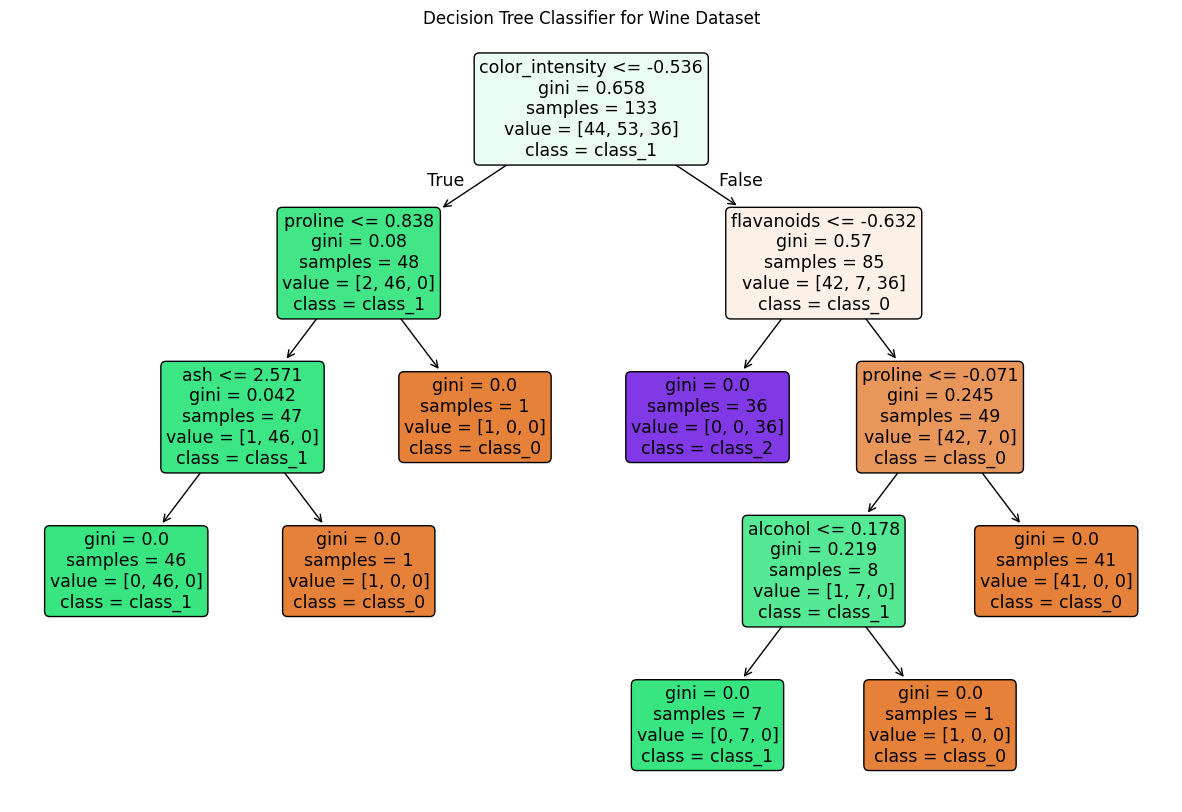

In [80]:
from sklearn.tree import plot_tree

# Extraer los nombres del dataframe, excluyendo el 'target'
feature_names = wine_df.drop('target', axis=1).columns.tolist()

# Nombres de clases
class_names = [str(c) for c in wine.target_names]

plt.figure(figsize=(15, 10))
plot_tree(
    dtree_classifier,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True
)
plt.title("Decision Tree Classifier for Wine Dataset")
plt.show()

Paso 7: En el nodo raiz podemos observar como la intensidad del color es relevante, pues es en base a este dato que se divide en verdadero y falso por primera vez lo cual nos ayuda a saber si contienen otra sustancia como el "proline" o "flavonoids" facilitando así su categorización.

